In [83]:
import pandas as pd
from pathlib import Path

data_path = Path.cwd().parent.parent / "data" / "raw"
order_data_path = data_path / "SHAB SRS 17_04_2026  Бланк заказа - Апрель 2026 (ОКС, ТК, КП).xls"

df = pd.read_excel(order_data_path, skiprows=14, sheet_name="Бланк заказа")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1151 entries, 0 to 1150
Data columns (total 58 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   КОД Продаж               1151 non-null   str    
 1   УКП                      1148 non-null   str    
 2   Бренд                    1148 non-null   str    
 3   Фабрика                  1140 non-null   str    
 4   Тип                      1148 non-null   str    
 5   Название SKU             1148 non-null   str    
 6   Заявка, короба           0 non-null      float64
 7   Заявка, шт.              0 non-null      float64
 8   Фокус                    1148 non-null   str    
 9   Группа ABC               1094 non-null   str    
 10  Признаки                 88 non-null     str    
 11  Фасовка - вес штуки, гр  1148 non-null   float64
 12  Вес короба, кг           1148 non-null   float64
 13  Вес заказа               1148 non-null   float64
 14  Срок годности, дн.       1148 non-n

In [84]:
print(df.columns.tolist())

['КОД Продаж', 'УКП', 'Бренд', 'Фабрика', 'Тип', 'Название SKU', 'Заявка, короба', 'Заявка, шт.', 'Фокус', 'Группа ABC', 'Признаки', 'Фасовка - вес штуки, гр', 'Вес короба, кг', 'Вес заказа', 'Срок годности, дн.', 'Базовая цена за короб', 'Сумма', 'Кол-во мест в слое', 'Кол-во мест в паллете', 'В кор. шт/кг', 'В ш-б  шт', 'кол-во ш-б в кор', 'Цена за шт/кг', 'Штрих код ед. продукта', 'Штрих код короба', 'Номер Сертификата', 'Размер короба', 'Кол-во слоев к отгрузке', 'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31', 'Unnamed: 32', 'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41', 'Unnamed: 42', 'Unnamed: 43', 'Unnamed: 44', 'Unnamed: 45', 'Unnamed: 46', 'Unnamed: 47', 'Unnamed: 48', 'Unnamed: 49', 'Unnamed: 50', 'Unnamed: 51', 'Unnamed: 52', 'Unnamed: 53', 'Unnamed: 54', 'Unnamed: 55', 'Unnamed: 56', 'Unnamed: 57']


In [85]:
cols_to_keep = [
    "Название SKU", "УКП", "Фокус", "Группа ABC", "Признаки", 
    "Тип", "Бренд", "Базовая цена за короб", 
    "Срок годности, дн.", "Фасовка - вес штуки, гр"
]
blanks_features = df[cols_to_keep].copy()

# 1. Бизнес-флаги
blanks_features["is_new"] = (blanks_features["Признаки"] == "Новинка").astype(int)
blanks_features["focus"] = blanks_features["Фокус"].fillna("Прочее")
blanks_features["abc_group"] = blanks_features["Группа ABC"].fillna("Unknown")

# 2. Характеристики товара
blanks_features["item_type"] = blanks_features["Тип"].fillna("Unknown")
blanks_features["brand"] = blanks_features["Бренд"].fillna("Unknown")

# Числовые признаки
blanks_features["base_price"] = blanks_features["Базовая цена за короб"]
blanks_features["shelf_life_days"] = blanks_features["Срок годности, дн."]
blanks_features["weight_gr"] = blanks_features["Фасовка - вес штуки, гр"]

# Оставляем только подготовленные колонки
final_features = blanks_features[[
    "Название SKU", "УКП", "is_new", "focus", "abc_group", 
    "item_type", "brand", "base_price", "shelf_life_days", "weight_gr"
]]

# Убираем первую техническую строку
final_features = final_features.iloc[1:].reset_index(drop=True) 

final_features.head()


,Название SKU,УКП,is_new,focus,abc_group,item_type,brand,base_price,shelf_life_days,weight_gr
0,ПИРОЖНЫЕ_БИСКВИТНЫЕ_Аленка_1/150,ЮК26025,1,ТОП66,CC,БИСКВИТЫ,ЮК,1522.56,270.0,150.0
1,ПИРОЖНЫЕ_БИСКВИТНЫЕ_Аленка_1/240,ЮК20760,0,ТОП66,AA,БИСКВИТЫ,ЮК,2625.72,270.0,240.0
2,ПИРОЖНЫЕ_БИСКВИТНЫЕ_Аленка_вкус_вареная_сгущен...,ЮК26023,1,ТОП66,CC,БИСКВИТЫ,ЮК,1522.56,270.0,150.0
3,ПИРОЖНЫЕ_БИСКВИТНЫЕ_Аленка_вкус_вареная_сгущен...,ЮК20789,0,ТОП66,AA,БИСКВИТЫ,ЮК,2058.72,270.0,200.0
4,ПИРОЖНЫЕ_БИСКВИТНЫЕ_Аленка_вкус_вареная_сгущен...,ЮК20767,0,ТОП66,AB,БИСКВИТЫ,ЮК,2625.72,270.0,240.0


In [86]:
print(final_features['focus'].unique())

<StringArray>
['ТОП66', 'Прочее', 'ЛА']
Length: 3, dtype: str


In [87]:
print(final_features['abc_group'].unique())

<StringArray>
['CC', 'AA', 'AB', 'BB', 'BA', 'CB', '--', 'BC', '-C', 'Unknown', 'AC']
Length: 11, dtype: str


In [88]:
print(final_features['item_type'].unique())

<StringArray>
[                'БИСКВИТЫ',                    'ВАФЛИ',
          'ЗЕФИР И ПАСТИЛА',                     'ИРИС',
                    'Какао',                 'КАРАМЕЛЬ',
       'КОНФЕТЫ В КОРОБКАХ',          'КОНФЕТЫ ВЕСОВЫЕ',
       'ПРЯНИКИ И КОВРИЖКИ',                    'ТОРТЫ',
                    'ХАЛВА',                  'ШОКОЛАД',
                  'Unknown', 'ГАЛЕТЫ И КРЕКЕРЫ, ХЛЕБЦЫ',
                    'ДРАЖЕ',         'ЗЛАКОВЫЕ ИЗДЕЛИЯ',
                     'КОФЕ',                 'Мармелад',
                  'ПЕЧЕНЬЕ', 'ПОЛУФАБРИКАТЫ НА СТОРОНУ',
         'ПРОЧИЕ МУЧНИСТЫЕ',        'ПРОЧИЕ САХАРИСТЫЕ']
Length: 22, dtype: str


In [89]:
final_features[final_features['Название SKU'] == "КОНФ ВЕС Столичные"]

,Название SKU,УКП,is_new,focus,abc_group,item_type,brand,base_price,shelf_life_days,weight_gr


In [90]:
# Загружаем исторические данные продаж
sales_path = data_path.parent / "clean" / "new_sales_data.csv"
sales_data = pd.read_csv(sales_path)

# Приклеиваем к продажам наши новые фичи из бланка заказа
# В sales_data название товара лежит в колонке "product"
sales_with_features = sales_data.merge(
    final_features, 
    left_on="sku", 
    right_on="УКП", 
    how="left"
)

# Удаляем дублирующуюся колонку
if "Название SKU" in sales_with_features.columns:
    sales_with_features = sales_with_features.drop(columns=["Название SKU"])

# Сохраняем финальный датасет, на котором мы будем обучать модели
final_dataset_path = data_path.parent / "clean" / "final_ml_dataset.csv"
sales_with_features.to_csv(final_dataset_path, index=False)

print(f"Итоговый датасет собран и сохранен в: {final_dataset_path}")
sales_with_features.head()


Итоговый датасет собран и сохранен в: /home/aleks/alenka_automation/data/clean/final_ml_dataset.csv


,product,sku,qty,unit,month,УКП,is_new,focus,abc_group,item_type,brand,base_price,shelf_life_days,weight_gr
0,КОНФ ВЕС Столичные,КО01828,63.586,кг,2023-12,КО01828,0.0,ТОП66,AA,КОНФЕТЫ ВЕСОВЫЕ,КО,7634.60,60.0,0.0
1,КОНФ ВЕС Сибирский Сувенир,НС07823,42.809,кг,2023-12,НС07823,0.0,ЛА,CB,ШОКОЛАД,НС,14402.00,120.0,0.0
2,КОНФ ВЕС Тамбовский волк Люкс,ТК07914,44.556,кг,2023-12,ТК07914,0.0,ЛА,BB,КОНФЕТЫ ВЕСОВЫЕ,ТК,5136.84,180.0,0.0
3,КОНФ ВЕС Сибирский сувенир Кедровый грильяж,НС20906,21.408,кг,2023-12,НС20906,0.0,ЛА,CB,КОНФЕТЫ ВЕСОВЫЕ,НС,16395.75,180.0,0.0
4,КОНФ ВЕС БУТЫЛОЧКИ С КОНЬЯКОМ,ЯП24671,22.819,кг,2023-12,ЯП24671,0.0,ЛА,BB,КОНФЕТЫ ВЕСОВЫЕ,ЯП,5194.53,45.0,0.0


In [91]:
# Убедимся, что колонка "month" имеет формат даты
sales_with_features["month"] = pd.to_datetime(sales_with_features["month"])


In [92]:
import numpy as np

def add_group_rolling(df: pd.DataFrame, base_col: str, new_col: str, window: int, func: str, min_periods: int = 1) -> None:
    df[new_col] = (
        df.groupby("product", sort=False)[base_col]
        .transform(lambda s: s.rolling(window=window, min_periods=min_periods).agg(func))
    )

def build_time_features(df: pd.DataFrame) -> tuple[pd.DataFrame, list[str]]:
    # Сортируем по товару и дате
    df = df.sort_values(["product", "month"]).reset_index(drop=True)
    qty_group = df.groupby("product", sort=False)["qty"]
    history = qty_group.shift(1)

    df["history"] = history
    df["history_non_zero"] = history.where(history > 0)
    df["history_is_non_zero"] = history.gt(0).astype(float)

    for lag in [1, 2, 3]:
        df[f"lag_{lag}"] = qty_group.shift(lag)

    add_group_rolling(df, "history", "ma3", window=3, func="mean")
    add_group_rolling(df, "history", "ma6", window=6, func="mean")
    add_group_rolling(df, "history", "median3", window=3, func="median")
    add_group_rolling(df, "history", "median6", window=6, func="median")
    add_group_rolling(df, "history_non_zero", "ma3_non_zero", window=3, func="mean")
    add_group_rolling(df, "history_is_non_zero", "non_zero_share_6", window=6, func="mean")

    df["lag_1_to_ma3"] = df["lag_1"] / (df["ma3_non_zero"].fillna(df["ma3"]).fillna(0.0) + 1.0)
    df["month_num"] = df["month"].dt.month
    df["month_sin"] = np.sin(2 * np.pi * df["month_num"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month_num"] / 12)

    # Временные фичи
    time_features = [
        "lag_1", "lag_2", "lag_3", "ma3", "ma6", "median3", "median6",
        "ma3_non_zero", "non_zero_share_6", "lag_1_to_ma3",
        "month_num", "month_sin", "month_cos"
    ]
    df[time_features] = df[time_features].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return df, time_features

feature_df, time_cols = build_time_features(sales_with_features)
feature_df.head()

,product,sku,qty,unit,month,УКП,is_new,focus,abc_group,item_type,...,ma3,ma6,median3,median6,ma3_non_zero,non_zero_share_6,lag_1_to_ma3,month_num,month_sin,month_cos
0,АКЦИЯ ПОМАДКА СЛИВОЧНАЯ С ЦУКАТАМИ 2+1 БЕСПЛАТНО,NaN,51.0,шт,2023-05-01,NaN,0.0,Прочее,Unknown,Unknown,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,5,5.000000e-01,-0.866025
1,АКЦИЯ ПОМАДКА СЛИВОЧНАЯ С ЦУКАТАМИ 2+1 БЕСПЛАТНО,NaN,51.0,шт,2023-05-01,NaN,0.0,Прочее,Unknown,Unknown,...,51.0,51.0,51.0,51.0,51.0,0.500000,0.980769,5,5.000000e-01,-0.866025
2,АКЦИЯ ПТИЧЬЕ МОЛОКО 2+1 БЕСПЛАТНО,NaN,97.0,шт,2023-06-01,NaN,0.0,Прочее,Unknown,Unknown,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,6,1.224647e-16,-1.000000
3,АКЦИЯ ПТИЧЬЕ МОЛОКО 2+1 БЕСПЛАТНО,NaN,97.0,шт,2023-06-01,NaN,0.0,Прочее,Unknown,Unknown,...,97.0,97.0,97.0,97.0,97.0,0.500000,0.989796,6,1.224647e-16,-1.000000
4,АКЦИЯ ПТИЧЬЕ МОЛОКО 2+1 БЕСПЛАТНО,NaN,20.0,шт,2023-07-01,NaN,0.0,Прочее,Unknown,Unknown,...,97.0,97.0,97.0,97.0,97.0,0.666667,0.989796,7,-5.000000e-01,-0.866025


In [93]:
print(feature_df.columns.tolist())

['product', 'sku', 'qty', 'unit', 'month', 'УКП', 'is_new', 'focus', 'abc_group', 'item_type', 'brand', 'base_price', 'shelf_life_days', 'weight_gr', 'history', 'history_non_zero', 'history_is_non_zero', 'lag_1', 'lag_2', 'lag_3', 'ma3', 'ma6', 'median3', 'median6', 'ma3_non_zero', 'non_zero_share_6', 'lag_1_to_ma3', 'month_num', 'month_sin', 'month_cos']


In [94]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Формируем финальный список фичей: Временные фичи + Фичи из экселя
cat_cols = ["is_new", "focus", "abc_group", "item_type", "brand"]
num_cols = ["base_price", "shelf_life_days", "weight_gr"]

# Преобразуем категориальные фичи для XGBoost
for col in cat_cols:
    if feature_df[col].dtype == "float64":
        feature_df[col] = feature_df[col].fillna(-1).astype(int).astype(str)
    else:
        feature_df[col] = feature_df[col].fillna("Unknown").astype(str)
    feature_df[col] = feature_df[col].astype("category")

feature_columns = time_cols + cat_cols + num_cols

# 2. Оставляем только те строки, где есть история (чтобы не учиться на пустых лагах)
model_df = feature_df.dropna(subset=["qty"]).copy()
model_df = model_df.sort_values(["product", "month"])

# 3. Делаем Time-Series Split (последние 2 месяца в тест, остальное в трейн)
unique_months = sorted(model_df["month"].unique())
train_months = unique_months[:-7]
test_months = unique_months[-7:]

train_df = model_df[model_df["month"].isin(train_months)]
test_df = model_df[model_df["month"].isin(test_months)]

X_train, y_train = train_df[feature_columns], train_df["qty"]
X_test, y_test = test_df[feature_columns], test_df["qty"]

print(f"Трейн: {len(X_train)} строк. Тест: {len(X_test)} строк.")


Трейн: 16328 строк. Тест: 4299 строк.


[0]	validation_0-tweedie-nloglik@1.5:19.23976


[50]	validation_0-tweedie-nloglik@1.5:16.67659
[100]	validation_0-tweedie-nloglik@1.5:16.65112
[150]	validation_0-tweedie-nloglik@1.5:16.65815
[200]	validation_0-tweedie-nloglik@1.5:16.65645
[250]	validation_0-tweedie-nloglik@1.5:16.65944
[299]	validation_0-tweedie-nloglik@1.5:16.66809

Средняя абсолютная ошибка (MAE) на тесте: 10.35


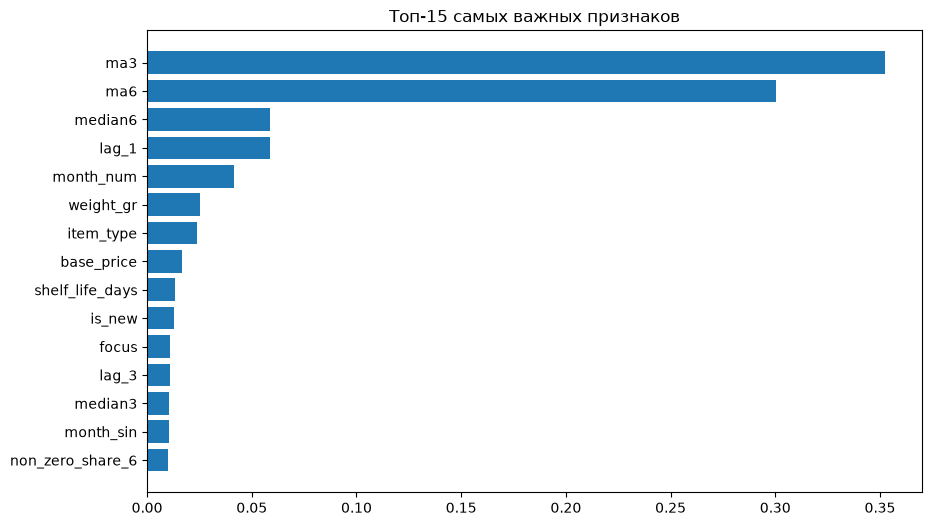

In [95]:
# 4. Обучаем финальную единую модель XGBoost с функцией потерь Tweedie!
# reg:tweedie отлично работает с товарами прерывистого спроса без необходимости писать двухэтапную модель

model = XGBRegressor(
    objective="reg:tweedie",
    tweedie_variance_power=1.5, # Этот параметр от 1 до 2 настраивает работу с нулями
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    enable_categorical=True,
    random_state=42
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=50)

# 5. Оценка
preds = np.clip(model.predict(X_test), 0, None) # Запрещаем отрицательные продажи
mae = mean_absolute_error(y_test, preds)

print(f"\nСредняя абсолютная ошибка (MAE) на тесте: {mae:.2f}")

# Для наглядности смотрим Feature Importances (что больше всего влияет на продажи)
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({"feature": feature_columns, "importance": model.feature_importances_})
importance_df = importance_df.sort_values("importance", ascending=False)
plt.figure(figsize=(10, 6))
plt.barh(importance_df["feature"][:15][::-1], importance_df["importance"][:15][::-1])
plt.title("Топ-15 самых важных признаков")
plt.show()


--- СЛУЧАЙНЫЕ ПРИМЕРЫ (где были продажи или прогноз) ---


,product,month,qty,prediction
600,Вафли МИЛКИ-ЛАКОМКИ с лимонным вкусом 450 г,2025-07-01,2.000,3.700000
2609,КОНФ ВЕС Аленка вафельные КРАСНЫЙ ОКТЯБРЬ 1 кг,2025-08-01,20.334,16.500000
4799,КОНФ ВЕС Красный мак,2025-09-01,9.941,11.800000
6010,КОНФ ВЕС Птичье молоко вкус нежные сливки,2025-11-01,14.348,6.600000
8826,КОНФ КОР Русь Тройка Ассорти 540 г,2025-12-01,23.000,32.700001
9670,Карамель Дюшес,2025-07-01,5.441,5.000000
15113,Пряник ТУЛЬСКИЙ с начинкой вареная сгущенка 140 г,2025-08-01,20.000,24.400000
17052,"Чай SIGURD зелёный Mao Feng (Мао Фенг) 15*1,7гр",2025-11-01,1.000,2.300000
18389,Шоколад Аленка с начинкой целый фундук и карам...,2025-10-01,15.000,9.100000
19318,Шоколад ВДОХНОВЕНИЕ Грушевый тарт со вкусом ма...,2025-09-01,16.000,19.600000


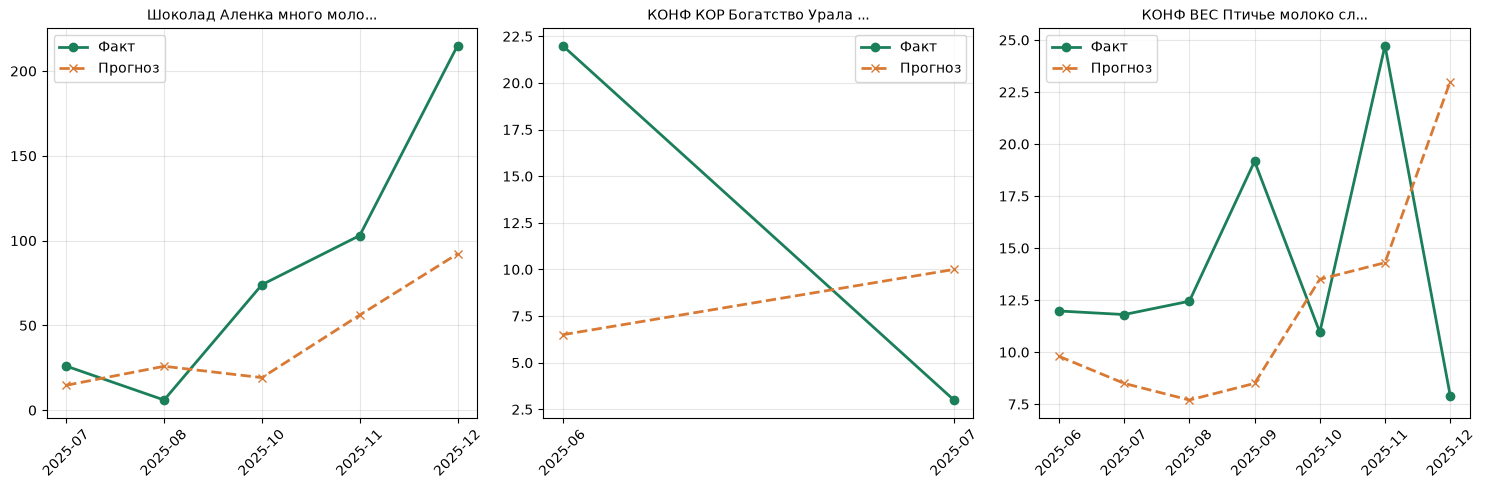

In [96]:
# Создаем датафрейм для сравнения глазами
results_df = test_df[["product", "month", "qty"]].copy()
results_df["prediction"] = np.round(preds, 1)  # Округляем прогноз для красоты

print("--- СЛУЧАЙНЫЕ ПРИМЕРЫ (где были продажи или прогноз) ---")
# Отбираем строки, где реально были продажи или модель предсказала больше 1 штуки
sample_view = results_df[(results_df["qty"] > 0) | (results_df["prediction"] > 1)]
if len(sample_view) > 10:
    display(sample_view.sample(10, random_state=42).sort_values(["product", "month"]))
else:
    display(sample_view)

# --- РИСУЕМ ГРАФИКИ ДЛЯ 3 СЛУЧАЙНЫХ ТОВАРОВ ---
# Выбираем 3 товара, у которых в тестовом периоде вообще были продажи
active_products = results_df[results_df["qty"] > 0]["product"].drop_duplicates()
if len(active_products) >= 3:
    sample_products = active_products.sample(3, random_state=42)
    
    plt.figure(figsize=(15, 5))
    for i, prod in enumerate(sample_products, 1):
        plt.subplot(1, 3, i)
        
        prod_data = results_df[results_df["product"] == prod].sort_values("month")
        
        # Переводим даты в строки вида Год-Месяц для красивой оси X
        x_labels = prod_data["month"].dt.strftime("%Y-%m")
        
        plt.plot(x_labels, prod_data["qty"], marker="o", label="Факт", linewidth=2, color="#1b7f5a")
        plt.plot(x_labels, prod_data["prediction"], marker="x", linestyle="--", label="Прогноз", linewidth=2, color="#d97a34")
        
        plt.title(f"{prod[:25]}...", fontsize=10)
        plt.xticks(rotation=45)
        plt.legend()
        plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


In [97]:
# Агрегируем результаты тестирования за весь тестовый период для каждого товара
summary_df = results_df.groupby("product").agg(
    total_fact=("qty", "sum"),
    total_pred=("prediction", "sum")
).reset_index()

# Считаем разницу (ошибку) в штуках/коробах
summary_df["error_abs"] = np.abs(summary_df["total_fact"] - summary_df["total_pred"])

# Подклеиваем бизнес-признаки, чтобы ты мог легко отфильтровать свои "ключевые" товары
sku_info = feature_df[["product", "focus", "abc_group", "item_type", "base_price"]].drop_duplicates(subset=["product"])
summary_df = summary_df.merge(sku_info, on="product", how="left")

# Сортируем по фактическому объему продаж по убыванию (самые ходовые - сверху)
summary_df = summary_df.sort_values("total_fact", ascending=False).reset_index(drop=True)

# Сохраняем в папку src/analytics
csv_path = "sku_predictions_summary.csv"
summary_df.to_csv(csv_path, index=False)

print(f"Готово! Сводная таблица по всем {len(summary_df)} товарам сохранена в файл: {csv_path}")
display(summary_df.head(15))


Готово! Сводная таблица по всем 809 товарам сохранена в файл: sku_predictions_summary.csv


,product,total_fact,total_pred,error_abs,focus,abc_group,item_type,base_price
0,Пакет-майка Аленка БИО малый 28*50,6652.0,4133.799805,2518.200195,Прочее,Unknown,Unknown,NaN
1,Пакет АЛЕНКА фирменный ПВД малый 33*45,4914.0,4087.600098,826.399902,Прочее,Unknown,Unknown,NaN
2,Шоколад Аленка молочный 15 гр КРАСНЫЙ ОКТЯБРЬ,2830.0,1831.000000,999.000000,ТОП66,AA,ШОКОЛАД,11392.50
3,Вода минеральная СЕНЕЖСКАЯ столовая негазирова...,1584.0,1704.599976,120.599976,Прочее,Unknown,Unknown,NaN
4,Шоколад Аленка молочный 20 гр КРАСНЫЙ ОКТЯБРЬ,1410.0,1437.099976,27.099976,ТОП66,AA,ШОКОЛАД,13235.20
5,ШОКОЛАД Медали 7г,1316.0,824.099976,491.900024,Прочее,CC,ШОКОЛАД,18150.00
6,Пакет АЛЕНКА фирменный ПВД большой 40*50,1248.0,1719.300049,471.300049,Прочее,Unknown,Unknown,NaN
7,Шоколад СКАЗКА молочный 15 г,1143.0,978.299988,164.700012,ЛА,BC,ШОКОЛАД,9240.42
8,Шоколад СКАЗКА молочный со взрывной карамелью ...,1137.0,1284.500000,147.500000,ЛА,CC,ШОКОЛАД,9240.42
9,Пакет-майка Аленка БИО большой 36*58,996.0,1065.699951,69.699951,Прочее,Unknown,Unknown,NaN


In [99]:
import optuna
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

def objective(trial):
    # Задаем пространство для поиска параметров
    param = {
        "objective": "reg:tweedie",
        "enable_categorical": True,
        "random_state": 42,
        
        "device": "cuda",
        
        # Перебираем глубину деревьев и количество
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        
        # Параметры от переобучения (регуляризация)
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        
        # Самый важный параметр для распределения Tweedie (от 1.1 до 1.9)
        "tweedie_variance_power": trial.suggest_float("tweedie_variance_power", 1.1, 1.9)
    }
    
    # Инициализируем модель с текущими параметрами
    model = XGBRegressor(**param)
    
    # Обучаем. Чтобы Optuna работала быстрее, выключаем verbose
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )
    
    # Предсказываем и считаем MAE (наша цель - минимизировать эту ошибку)
    preds = np.clip(model.predict(X_test), 0, None)
    mae = mean_absolute_error(y_test, preds)
    return mae

# Создаем Study: мы хотим минимизировать ошибку (direction="minimize")
study = optuna.create_study(direction="minimize")
# Запускаем перебор. Для начала 30 попыток (trials), потом можно увеличить до 100
study.optimize(objective, n_trials=200)

print("\nЛучшие гиперпараметры, которые нашла Optuna:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

# Теперь берем лучшие параметры и обучаем финальную "супер-модель"
best_params = study.best_params
best_params["objective"] = "reg:tweedie"
best_params["enable_categorical"] = True
best_params["random_state"] = 42

final_best_model = XGBRegressor(**best_params)
final_best_model.fit(X_train, y_train, verbose=False)

# Считаем новую ошибку
optuna_preds = np.clip(final_best_model.predict(X_test), 0, None)
optuna_mae = mean_absolute_error(y_test, optuna_preds)
print(f"\nMAE базовой модели: {mae:.2f} (из предыдущей ячейки)")
print(f"MAE после подбора Optuna: {optuna_mae:.2f}")


[I 2026-06-24 16:54:53,052] A new study created in memory with name: no-name-dee340e1-f201-48ac-98df-73eb30336f8a
/home/aleks/alenka_automation/.venv/lib/python3.14/site-packages/xgboost/core.py:553: UserWarning: [16:54:59] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
[I 2026-06-24 16:54:59,329] Trial 0 finished with value: 10.284307015699186 and parameters: {'max_depth': 9, 'n_estimators': 572, 'learning_rate': 0.010450150291679703, 'subsample': 0.6690598920669831, 'colsample_bytree': 0.6333800067394423, 'min_child_weight': 6, 'tweedie_variance_power': 1.3151372594801


Лучшие гиперпараметры, которые нашла Optuna:
  max_depth: 8
  n_estimators: 514
  learning_rate: 0.020190704602494485
  subsample: 0.856584168123017
  colsample_bytree: 0.6712263048282858
  min_child_weight: 8
  tweedie_variance_power: 1.8607348638588146

MAE базовой модели: 10.35 (из предыдущей ячейки)
MAE после подбора Optuna: 10.04


In [100]:
import json

final_best_model.save_model("models/xgboost_tweedie_model.json")